# 02 — AX-21 isotherm: data vs. published-parameter model (Gate V2, part 1)

Builds Figure **F2** (§3.10): the digitized 77 K AX-21 excess data, the modified
Dubinin–Astakhov model at the **published** parameters (excess and absolute shown
separately), and the residuals. Computes the RMSE between model excess and the
digitized points and compares it to the threshold pre-registered in
`docs/validation_plan.md` (Gate V2, part 1, §3.8).

The refit ("your fit") line is added on the next step (CC-4); F2 is completed then.

**Data provenance.** `data/validation/ax21_digitized.csv` — the 77 K excess isotherm
(× markers) digitized from Fig. 1(a) of Richard, Bénard & Chahine, *Adsorption*
**15**:43–51 (2009), DOI 10.1007/s10450-009-9149-x. All physics lives in `h2star`;
this notebook only orchestrates package calls and plots (§4.3).

In [4]:
from pathlib import Path
import io

import numpy as np

from h2star.isotherm import Material, ModifiedDA, rmse
from h2star.viz import plot_ax21_isotherm

REPO_ROOT = Path.cwd()
DIGITIZED = REPO_ROOT / "data" / "validation" / "ax21_digitized.csv"
AX21_YAML = REPO_ROOT / "data" / "materials" / "ax21.yaml"
FIG_PATH = REPO_ROOT / "figures" / "F2_ax21_isotherm.png"

lines = [
    ln for ln in DIGITIZED.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
]
raw = np.genfromtxt(io.StringIO("\n".join(lines)), delimiter=",", names=True)

P_data_mpa = np.asarray(raw["pressure_mpa"], dtype=float)
n_exc_data = np.asarray(raw["n_excess_mol_kg"], dtype=float)

_order = np.argsort(P_data_mpa)
P_data_mpa = P_data_mpa[_order]
n_exc_data = n_exc_data[_order]

In [5]:
T = 77.0  # K — temperature of the digitized isotherm (Fig. 1a, 77 K curve)

material = Material.from_yaml(AX21_YAML)
da = ModifiedDA(material)

P_data_pa = P_data_mpa * 1e6
n_exc_model_at_data = da.n_excess(P_data_pa, T)
residuals = n_exc_model_at_data - n_exc_data
rmse_value = rmse(n_exc_model_at_data, n_exc_data)

P_curve_pa = np.logspace(np.log10(P_data_pa.min()), np.log10(P_data_pa.max()), 400)
n_exc_curve = da.n_excess(P_curve_pa, T)
n_abs_curve = da.n_absolute(P_curve_pa, T)

print(f"Gate V2 part 1 — RMSE(model excess vs digitized, 77 K) = {rmse_value:.3f} mol/kg")

Gate V2 part 1 — RMSE(model excess vs digitized, 77 K) = 1.109 mol/kg


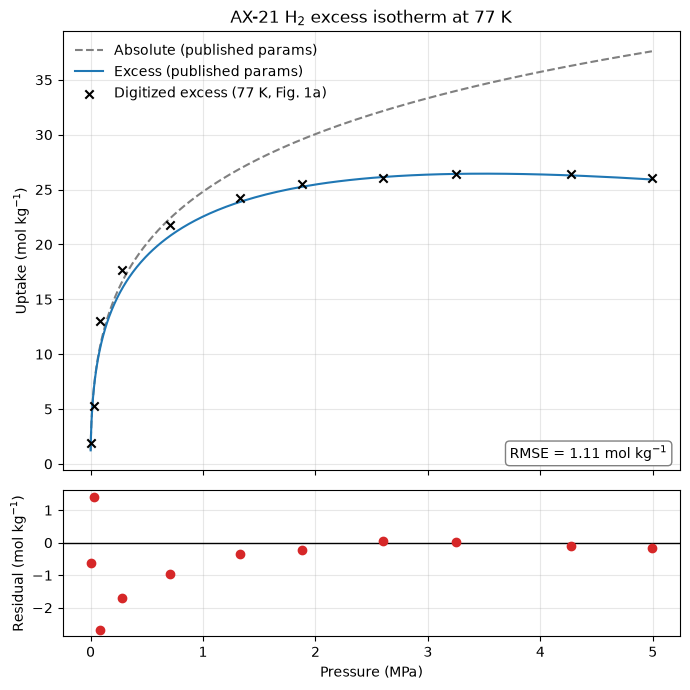

In [6]:
fig = plot_ax21_isotherm(
    P_data_mpa=P_data_mpa,
    n_excess_data=n_exc_data,
    P_curve_mpa=P_curve_pa / 1e6,
    n_excess_curve=n_exc_curve,
    n_absolute_curve=n_abs_curve,
    residuals=residuals,
    rmse_value=rmse_value,
    savepath=FIG_PATH,
)